In [64]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import shutil
import os


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.lite.python.interpreter import Interpreter as tflite

In [65]:
DATA_DIR_ALL = "D:\\c2c\\projekt_phase_2\\img\\"
DATA_DIR_USE = "D:\\c2c\\projekt_phase_2\\img_use\\"
IMG_SIZE = (224, 224)

In [29]:
paths  = Path(DATA_DIR_ALL).glob("*RAW*")
for p in paths:
    shutil.copy2(str(p), os.path.join(DATA_DIR_USE, os.path.split(str(p))[1]))

In [67]:
#IMG_RAW_SRC_d7abb528_20260303_08-31-02_3939_S050_A135.jpg
#[IMG, RAW, SRC,d7abb528, 20260303, 08-31-02, 3939, S050, A135.jpg]
# A135.jpg
# [A135, .jpg]
def load_images_and_labels(folder, file_date):
  paths = Path(folder).glob(f'*RAW*.png')
  imgs = []
  labels = []
  for p in paths:
    img = cv2.imread(str(p))
    imgs.append(img)
    label = str(p).split("_")[-1].split(".")[0][1:]
    labels.append(int(label))
  return imgs, labels

In [68]:
#load_images_and_labels(DATA_DIR_USE, '20260303')
imgs, labels = load_images_and_labels(DATA_DIR_USE, '20260303')

In [70]:
len(imgs)

924

In [71]:
len(labels)

924

In [72]:
labels

[79,
 78,
 78,
 84,
 93,
 100,
 108,
 113,
 115,
 112,
 104,
 89,
 72,
 55,
 45,
 45,
 45,
 45,
 45,
 46,
 52,
 60,
 68,
 77,
 85,
 91,
 94,
 90,
 84,
 73,
 64,
 55,
 48,
 46,
 46,
 50,
 64,
 71,
 82,
 94,
 101,
 108,
 108,
 106,
 102,
 94,
 85,
 77,
 71,
 66,
 64,
 64,
 63,
 64,
 62,
 60,
 60,
 62,
 68,
 74,
 74,
 74,
 72,
 71,
 66,
 57,
 50,
 45,
 45,
 45,
 45,
 45,
 48,
 61,
 69,
 79,
 91,
 98,
 102,
 102,
 94,
 87,
 78,
 71,
 64,
 60,
 57,
 53,
 51,
 52,
 54,
 54,
 66,
 68,
 70,
 79,
 82,
 85,
 88,
 88,
 87,
 85,
 82,
 80,
 76,
 73,
 71,
 68,
 67,
 65,
 63,
 63,
 63,
 64,
 66,
 67,
 66,
 67,
 66,
 66,
 66,
 64,
 64,
 63,
 62,
 62,
 62,
 64,
 66,
 70,
 74,
 81,
 85,
 90,
 93,
 94,
 94,
 91,
 88,
 85,
 81,
 77,
 71,
 65,
 61,
 55,
 54,
 56,
 60,
 60,
 73,
 76,
 79,
 80,
 77,
 72,
 66,
 60,
 56,
 52,
 50,
 49,
 47,
 50,
 53,
 56,
 60,
 66,
 69,
 71,
 71,
 68,
 68,
 69,
 70,
 71,
 74,
 75,
 78,
 81,
 85,
 88,
 91,
 93,
 92,
 91,
 90,
 90,
 90,
 90,
 90,
 89,
 90,
 88,
 85,
 82,
 78,
 7

In [73]:
def preprocess_images(imgs, target_size=IMG_SIZE):
  out = [cv2.resize(img, target_size) for img in imgs]
  out = np.asarray(out) / 255
  return out

In [74]:
X = preprocess_images(imgs)

In [75]:
y = np.asarray(labels)

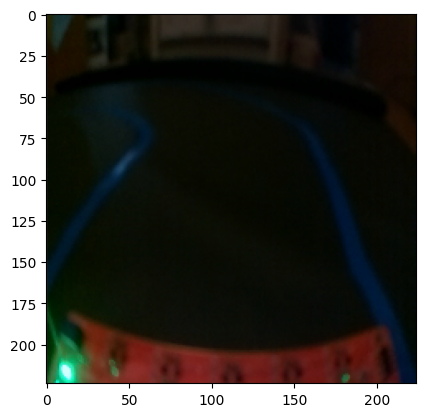

In [76]:
plt.imshow(X[0, :, :, ::-1])

In [77]:
def show_examples(images, labels, n=8, title="Beispiele"):
    n = min(n, len(images))
    idx = np.random.choice(len(images), n, replace=False)
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(12, 3*rows))
    for i, j in enumerate(idx, 1):
        plt.subplot(rows, cols, i)
        img = images[j]
        if img.dtype != np.uint8:
            img = (np.clip(img, 0, 1) * 255).astype(np.uint8)
        plt.imshow(img[:,:,::-1]); plt.title(f"Label: {labels[j]}"); plt.axis("off")
    plt.suptitle(title); plt.tight_layout(); plt.show()

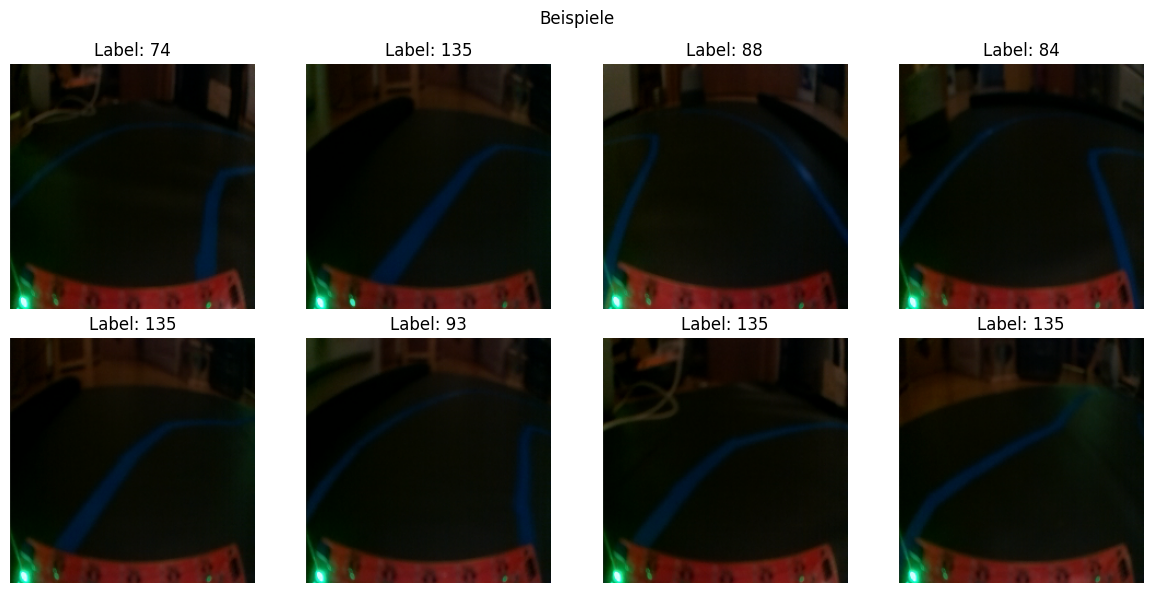

In [78]:
show_examples(X, y)

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
X_train.shape

(739, 224, 224, 3)

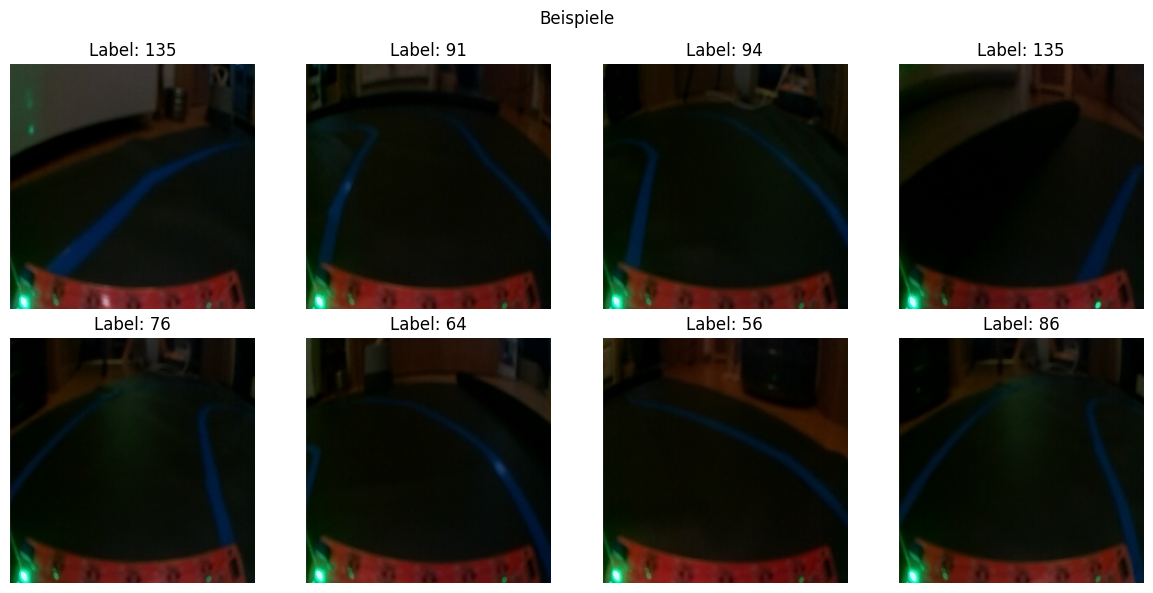

In [81]:
show_examples(X_train, y_train)

In [124]:
def mirror_images(images, labels):
  X_m = [img[:,::-1,:] for img in images]
  y_m = [180 - label for label in labels]

  return X_m, y_m

In [125]:
X_train_m, y_train_m = mirror_images(X_train, y_train)

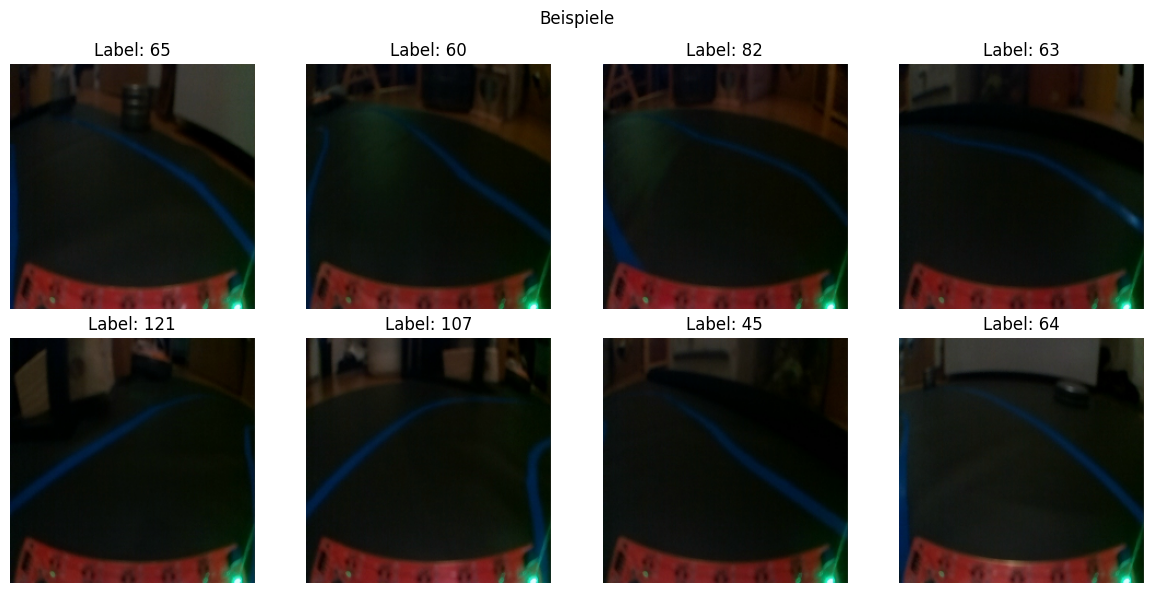

In [126]:
show_examples(X_train_m, y_train_m)

In [82]:
X_train_pool = X_train
y_train_pool = y_train
#X_train_pool = np.concatenate([X_train, X_train_m])
#y_train_pool = np.concatenate([y_train, y_train_m])

In [83]:
X_train_pool.shape

(739, 224, 224, 3)

(array([20., 12., 22., 20.,  8., 14., 20., 17.,  9., 43.]),
 array([ 45.,  54.,  63.,  72.,  81.,  90.,  99., 108., 117., 126., 135.]),
 <BarContainer object of 10 artists>)

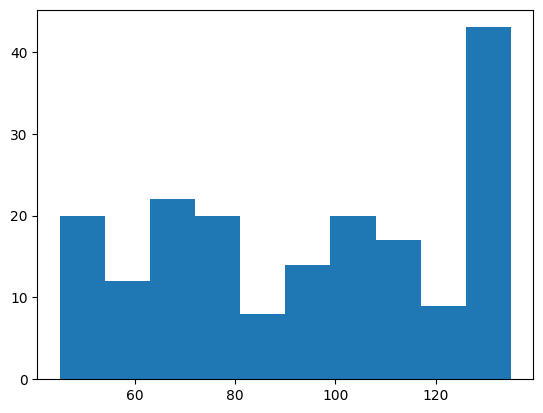

In [84]:
plt.hist(y_test)

In [ ]:
(224, 244)
224, 244

In [85]:
size = X_train_pool.shape[1:]

In [86]:
model = keras.Sequential([
    layers.Input(size),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(90, activation="relu"),
    layers.Dense(1)
])

In [87]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [88]:
history = model.fit(X_train_pool, y_train_pool, epochs=10, batch_size=128, validation_data=(X_test, y_test), verbose=1)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 7089.6265 - mae: 76.5198 - val_loss: 1234.7190 - val_mae: 28.3551
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 1700.3207 - mae: 34.9122 - val_loss: 1286.6163 - val_mae: 28.7331
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 1563.7394 - mae: 31.4847 - val_loss: 1303.0168 - val_mae: 28.8336
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 1052.0718 - mae: 26.8965 - val_loss: 1209.4741 - val_mae: 30.2701
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 975.9855 - mae: 25.9977 - val_loss: 1131.2461 - val_mae: 27.1013
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 858.0140 - mae: 24.1228 - val_loss: 849.1780 - val_mae: 25.0993
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 734.9048 - mae: 22.9087 - val_loss: 689.3649 - val_mae: 22.1939
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 549.8572 - mae: 19.5781 - val_loss: 459.3050 - val_mae: 17.3666
Epoch 9/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 

In [89]:
211.1509**0.5

14.531032310197373

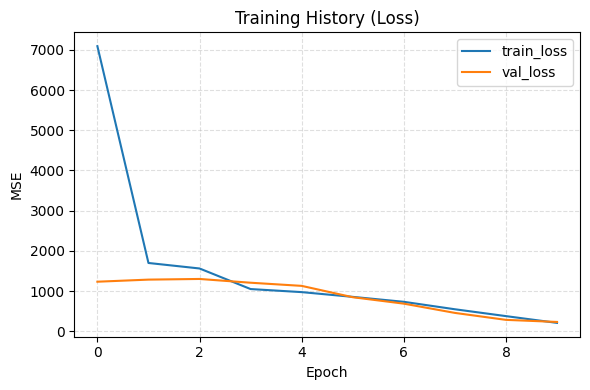

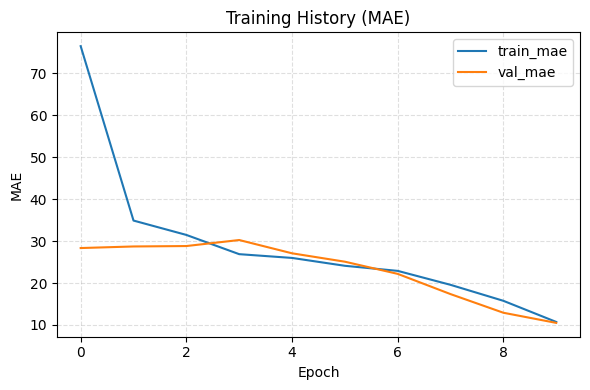

In [90]:
# History-Plots
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("Training History (Loss)")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.4); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["mae"], label="train_mae")
plt.plot(history.history["val_mae"], label="val_mae")
plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.title("Training History (MAE)")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.4); plt.tight_layout(); plt.show()

In [91]:
y_pred = model.predict(X_test).ravel()

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step


In [92]:
y_pred

array([ 63.37706 ,  73.794876,  57.78597 , 128.5326  , 129.47774 ,
        55.688618,  78.26234 ,  52.66931 ,  88.34472 , 115.9216  ,
        50.327087, 135.96942 ,  53.995594, 135.1001  ,  61.02711 ,
        60.47599 ,  44.229813,  79.51626 , 139.34695 ,  53.10548 ,
       117.8813  , 110.268105, 146.29276 ,  96.9764  ,  71.06937 ,
        98.58784 ,  71.82069 , 127.72455 , 147.01993 , 110.49867 ,
       151.56647 ,  65.6156  ,  54.875473,  76.74398 , 105.80039 ,
       107.63907 ,  89.156654, 105.93067 , 144.54134 ,  83.40336 ,
        79.44177 ,  76.842186, 110.302155,  66.232765, 128.29834 ,
       107.37813 ,  45.3601  ,  85.880974,  70.820885, 129.56013 ,
        63.24225 ,  90.055176,  94.75243 ,  90.642006,  87.27828 ,
        83.18333 , 108.45216 ,  80.926834, 144.82701 ,  73.30073 ,
        69.123825,  61.26531 ,  67.16347 , 101.88069 ,  49.159035,
       118.293594,  91.01174 , 106.24978 , 141.63794 ,  59.173306,
        76.53784 , 105.13639 ,  87.957985,  93.206314, 123.556

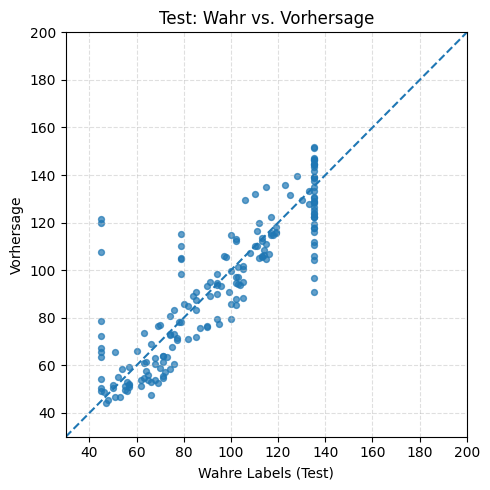

In [93]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, s=18, alpha=0.7)
plt.plot([30,200],[30,200], linestyle="--")
plt.xlim(30,200); plt.ylim(30,200)
plt.xlabel("Wahre Labels (Test)"); plt.ylabel("Vorhersage")
plt.title("Test: Wahr vs. Vorhersage"); plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [94]:
error = abs(y_test - y_pred)

In [95]:
error

array([ 9.62294006, 10.7948761 ,  6.21403122,  6.46740723, 23.47773743,
       15.31138229,  0.73766327, 16.33068848, 16.65528107, 19.07839966,
        5.3270874 , 12.96942139, 14.00440598, 20.10009766,  1.97288895,
       15.5240097 ,  2.77018738, 14.48374176,  4.34695435,  2.89451981,
       17.11869812,  0.73189545, 11.29275513,  5.02359772, 10.93063354,
        4.58783722, 13.17931366,  5.27545166, 12.01992798, 24.50132751,
       16.56646729, 14.61560059,  8.12452698,  7.74398041,  7.19960785,
       62.6390686 ,  1.84334564,  8.93067169,  9.54133606,  1.59664154,
       20.55822754,  6.84218597, 31.30215454,  6.2327652 ,  6.70166016,
        0.62187195,  2.63990021,  5.88097382,  6.1791153 ,  0.43986511,
        4.75775146,  3.94482422,  7.24756622,  5.64200592,  2.27828217,
        7.18332672,  5.5478363 ,  6.92683411,  9.82701111,  2.69927216,
        3.12382507,  2.73469162, 22.16346741,  3.11930847,  4.15903473,
        0.70640564,  7.98825836,  7.75022125,  6.63793945,  2.17

In [96]:
np.argmax(error)

np.int64(120)

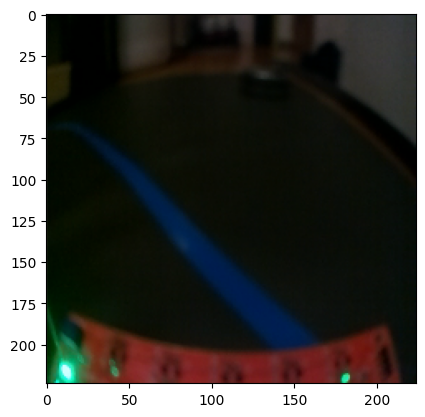

In [97]:
plt.imshow(X_test[120, :, :, ::-1])

In [98]:
print(y_test[120], y_pred[120])

45 121.54365


In [99]:
model.save("live_model.keras")

In [100]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\Besitzer\AppData\Local\Temp\tmp6ubu98eo\assets


INFO:tensorflow:Assets written to: C:\Users\Besitzer\AppData\Local\Temp\tmp6ubu98eo\assets


Saved artifact at 'C:\Users\Besitzer\AppData\Local\Temp\tmp6ubu98eo'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2853037308432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853037305552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853037480976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853033409040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853037295376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853038180304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853038178768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853038181264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853038180496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853038182224: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [101]:
with open("live_model_tflite.tflite", "wb") as f:
  f.write(tflite_model)

In [ ]:
interpreter = tflite.Interpreter(model_path="/home/pi/Desktop/git/c2c_Phase2/Software/live_model_fp32.tflite")
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
interpreter.allocate_tensors()

In [ ]:
img = np.expand_dims(img, axis=0)

In [ ]:
interpreter.set_tensor(input_details[0]['index'], img)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
int(output_data)

In [76]:
X_train_pool.shape

(114, 224, 224, 3)